# Ecommerce

In [ ]:
# This command installs the 'lifetimes' package using pip. 'lifetimes' is useful for CLV analysis.
!pip install lifetimes
# The squarify library in Python provides a way to visualize data as treemaps
!pip install squarify

In [ ]:
import pandas as pd  # Used for data manipulation and analysis.
import numpy as np  # Supports large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
from google.colab import files  # Facilitates file uploads and downloads in Google Colab environment.

# Import BetaGeoFitter and GammaGammaFitter for customer lifetime value analysis:
from lifetimes import BetaGeoFitter, GammaGammaFitter  # Models for predicting and analyzing customer behavior.

# Import utility functions for customer lifetime value models:
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data  # Transform transaction data into suitable format for CLV models.

import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations in Python.
import seaborn as sns  # Based on matplotlib, provides a high-level interface for drawing attractive and informative statistical graphics.
from matplotlib.colors import LinearSegmentedColormap  # For creating custom colormaps.

from itertools import combinations  # For efficient looping through pairs, triplets, etc., of data items.
from collections import Counter  # Provides a count of occurrences for hashable objects.

import squarify  # For generating treemaps that can visualize hierarchical data.

# Import specific plotting functions from lifetimes package:
from lifetimes.plotting import plot_probability_alive_matrix, plot_calibration_purchases_vs_holdout_purchases
from lifetimes.plotting import plot_period_transactions
from lifetimes.plotting import plot_frequency_recency_matrix  # Various plots specific to customer behavior analysis and CLV modeling.


In [ ]:
# Reading the parquet file
ecom_df = pd.read_parquet('/content/ecom_202412061441.parquet')


In [ ]:
# Initial data exploration to understand the structure
print("Initial data structure:")
print(ecom_df.head())

Initial data structure:
        id  ordernumber           ordertime currency  subshopID  userID  \
0  1822075       232060 2024-11-19 07:54:09      EUR          1  271223   
1  1822072       232059 2024-11-19 07:49:33      EUR          1  271218   
2  1822072       232059 2024-11-19 07:49:33      EUR          1  271218   
3  1822067       232058 2024-11-19 07:18:03      EUR          1  271220   
4  1822067       232058 2024-11-19 07:18:03      EUR          1  271220   

   customernumber                            oberalp_id  \
0          277423                                  None   
1          277418  a14bd204-36a6-ef11-b8e9-0022489d94f7   
2          277418  a14bd204-36a6-ef11-b8e9-0022489d94f7   
3          277420  69fe8282-3da6-ef11-8a6a-000d3ab21097   
4          277420  69fe8282-3da6-ef11-8a6a-000d3ab21097   

         articleordernumber            ean  price  quantity rma_article  \
0  00-0000061410_0000000007  4053866473422  360.0         1        None   
1  00-0000027257_000

In [ ]:
# Checking information of data
print("\nData types and missing values:")
print(ecom_df.info())


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400380 entries, 0 to 400379
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  400380 non-null  int64         
 1   ordernumber         400380 non-null  int64         
 2   ordertime           400380 non-null  datetime64[us]
 3   currency            400380 non-null  object        
 4   subshopID           400380 non-null  int64         
 5   userID              400380 non-null  int64         
 6   customernumber      400380 non-null  int64         
 7   oberalp_id          230106 non-null  object        
 8   articleordernumber  400380 non-null  object        
 9   ean                 400380 non-null  int64         
 10  price               400380 non-null  float64       
 11  quantity            400380 non-null  int64         
 12  rma_article         84977 non-null   object        
 1

Modify the formatting for below!!!

In [ ]:
# Calculate total products sold
total_sold = ecom_df['quantity'].sum()

# Calculate total products returned
total_returned = ecom_df['rma_quantity'].fillna(0).sum()

# Calculate net products sold
net_products_sold = total_sold - total_returned

# Calculate revenue generated and lost
revenue_generated = (ecom_df['quantity'] * ecom_df['price']).sum()
revenue_lost = (ecom_df['rma_quantity'].fillna(0) * ecom_df['price']).sum()

total_sold, total_returned, net_products_sold, revenue_generated, revenue_lost

(418896, 86007.0, 332889.0, 51285740.892, 12672982.000000006)

In [ ]:
# Finding the customer with the most purchases
most_purchases_customer = ecom_df.groupby('customernumber')['quantity'].sum().idxmax()

# Finding the customer with the most returns
most_returns_customer = ecom_df.groupby('customernumber')['rma_quantity'].sum().idxmax()

most_purchases_customer, most_returns_customer


(99330, 124883)

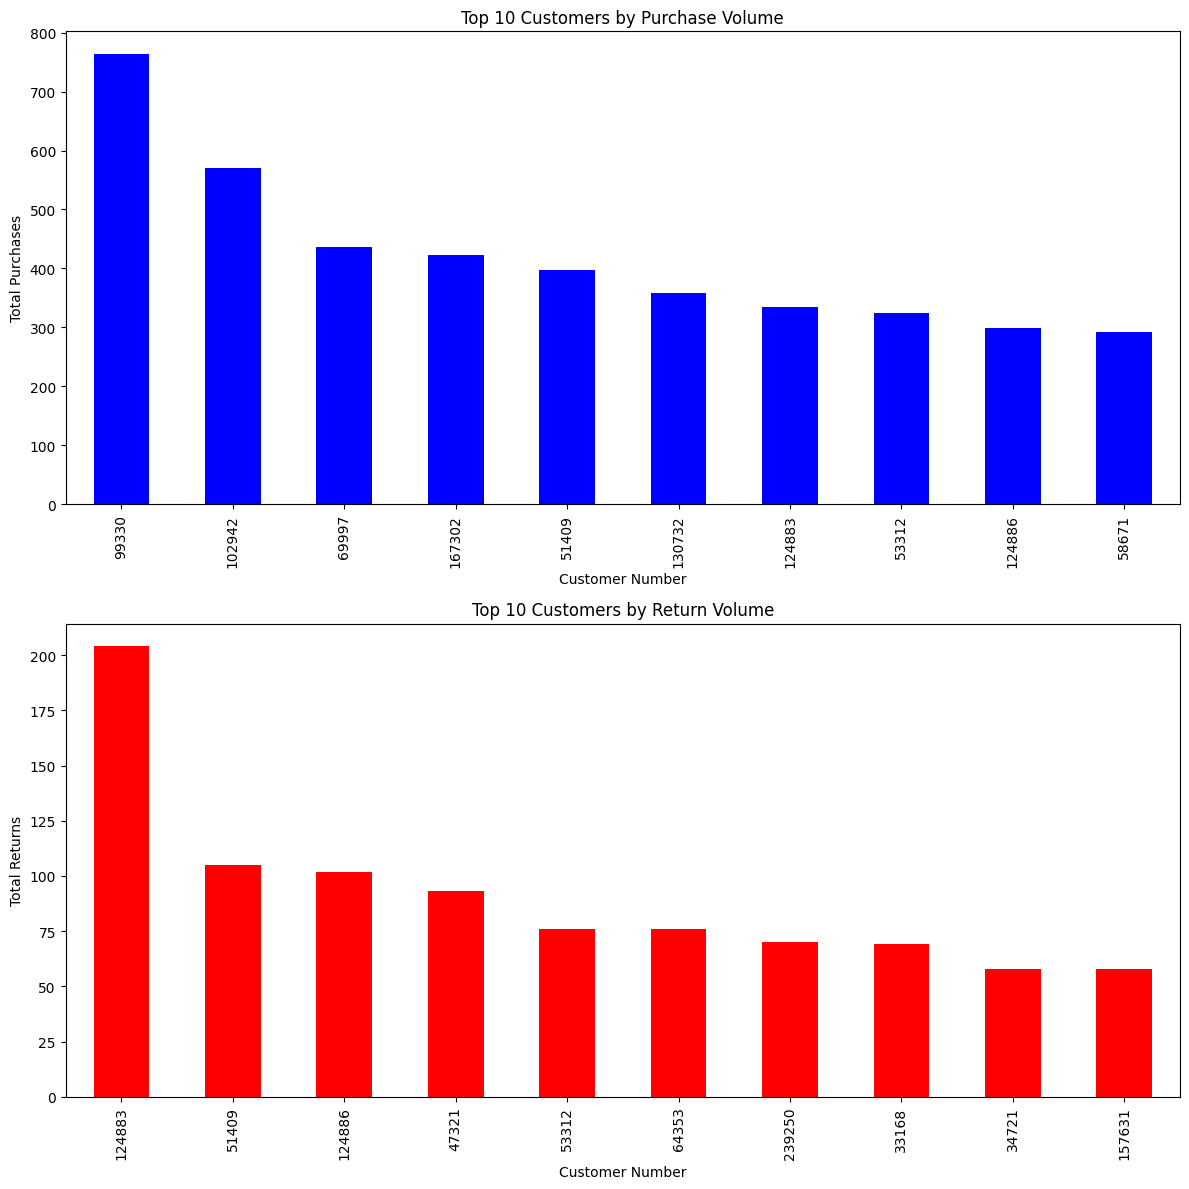

In [ ]:
# Setting up the data for the graphs
top_customers_purchases = ecom_df.groupby('customernumber')['quantity'].sum().nlargest(10)
top_customers_returns = ecom_df.groupby('customernumber')['rma_quantity'].sum().nlargest(10)

# Creating a figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# Top 10 customers by purchase volume
top_customers_purchases.plot(kind='bar', color='blue', ax=ax[0])
ax[0].set_title('Top 10 Customers by Purchase Volume')
ax[0].set_xlabel('Customer Number')
ax[0].set_ylabel('Total Purchases')

# Top 10 customers by return volume
top_customers_returns.plot(kind='bar', color='red', ax=ax[1])
ax[1].set_title('Top 10 Customers by Return Volume')
ax[1].set_xlabel('Customer Number')
ax[1].set_ylabel('Total Returns')

plt.tight_layout()
plt.show()


In [ ]:
# Extract the year from 'ordertime'
ecom_df['ordertime'] = pd.to_datetime(ecom_df['ordertime'])
ecom_df['year'] = ecom_df['ordertime'].dt.year

# Calculate Total Purchases and Total Returns
ecom_df['total_purchases'] = ecom_df.groupby('customernumber')['quantity'].transform('sum')
ecom_df['total_returns'] = ecom_df.groupby('customernumber')['rma_quantity'].transform('sum')

ecom_df.head()

,id,ordernumber,ordertime,currency,subshopID,userID,customernumber,oberalp_id,articleordernumber,ean,price,quantity,rma_article,rma_quantity,year,total_purchases,total_returns
0,1822075,232060,2024-11-19 07:54:09,EUR,1,271223,277423,None,00-0000061410_0000000007,4053866473422,360.0,1,None,NaN,2024,1,0.0
1,1822072,232059,2024-11-19 07:49:33,EUR,1,271218,277418,a14bd204-36a6-ef11-b8e9-0022489d94f7,00-0000027257_0000000057,4053866037686,99.0,1,None,NaN,2024,2,0.0
2,1822072,232059,2024-11-19 07:49:33,EUR,1,271218,277418,a14bd204-36a6-ef11-b8e9-0022489d94f7,00-0000027257_0000000092,4053866334389,99.0,1,None,NaN,2024,2,0.0
3,1822067,232058,2024-11-19 07:18:03,EUR,1,271220,277420,69fe8282-3da6-ef11-8a6a-000d3ab21097,00-0000028674_0000000011,4053866590013,270.0,1,None,NaN,2024,2,0.0
4,1822067,232058,2024-11-19 07:18:03,EUR,1,271220,277420,69fe8282-3da6-ef11-8a6a-000d3ab21097,00-0000028674_0000000022,4053866633970,270.0,1,None,NaN,2024,2,0.0


In [ ]:
# Calculate the number of years a customer has interacted with the company
customer_years = ecom_df.groupby('customernumber')['year'].nunique().reset_index()
customer_years.rename(columns={'year': 'years_connected'}, inplace=True)

# Get top 10 customers based on total purchases and total returns
top_10_purchase = ecom_df.groupby('customernumber')['total_purchases'].max().nlargest(10)
top_10_return = ecom_df.groupby('customernumber')['total_returns'].max().nlargest(10)

# Display the top 10 customers for purchases and returns to verify
top_10_purchase, top_10_return


(customernumber
 99330     764
 102942    571
 69997     437
 167302    423
 51409     398
 130732    359
 124883    334
 53312     324
 124886    299
 58671     293
 Name: total_purchases, dtype: int64,
 customernumber
 124883    204.0
 51409     105.0
 124886    102.0
 47321      93.0
 53312      76.0
 64353      76.0
 239250     70.0
 33168      69.0
 34721      58.0
 157631     58.0
 Name: total_returns, dtype: float64)

In [ ]:
# Reset index to avoid ambiguity when merging
top_10_purchase = top_10_purchase.reset_index()
top_10_return = top_10_return.reset_index()

# Merge the top customers with the number of years they have been connected with the company
top_10_purchase_years = top_10_purchase.merge(customer_years, on='customernumber')
top_10_return_years = top_10_return.merge(customer_years, on='customernumber')

# Display merged data to check
top_10_purchase_years, top_10_return_years


(   customernumber  total_purchases  years_connected
 0           99330              764                4
 1          102942              571                4
 2           69997              437                5
 3          167302              423                2
 4           51409              398                6
 5          130732              359                4
 6          124883              334                4
 7           53312              324                5
 8          124886              299                4
 9           58671              293                5,
    customernumber  total_returns  years_connected
 0          124883          204.0                4
 1           51409          105.0                6
 2          124886          102.0                4
 3           47321           93.0                4
 4           53312           76.0                5
 5           64353           76.0                5
 6          239250           70.0                1
 7      

In [ ]:
# Plotting the graphs
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Bar plot for Top 10 Customers by Purchase Volume
sns.barplot(x=top_10_purchase_years['total_purchases'], y=top_10_purchase_years['customernumber'], ax=axes[0], palette='Blues')
axes[0].set_title('Top 10 Customers by Purchase Volume', fontsize=16)
axes[0].set_xlabel('Total Purchases', fontsize=12)
axes[0].set_ylabel('Customer Number', fontsize=12)
for i in range(len(top_10_purchase_years)):
    axes[0].text(top_10_purchase_years['total_purchases'].iloc[i] + 10, i, f"Year(s) Connected: {top_10_purchase_years.loc[i, 'years_connected']}",
                 va='center', fontsize=10)

# Bar plot for Top 10 Customers by Return Volume
sns.barplot(x=top_10_return_years['total_returns'], y=top_10_return_years['customernumber'], ax=axes[1], palette='Reds')
axes[1].set_title('Top 10 Customers by Return Volume', fontsize=16)
axes[1].set_xlabel('Total Returns', fontsize=12)
axes[1].set_ylabel('Customer Number', fontsize=12)
for i in range(len(top_10_return_years)):
    axes[1].text(top_10_return_years['total_returns'].iloc[i] + 10, i, f"Year(s) Connected: {top_10_return_years.loc[i, 'years_connected']}",
                 va='center', fontsize=10)

plt.tight_layout()
plt.show()


<ipython-input-12-5bd14d25e66a>:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


 Product Category Sales Performance

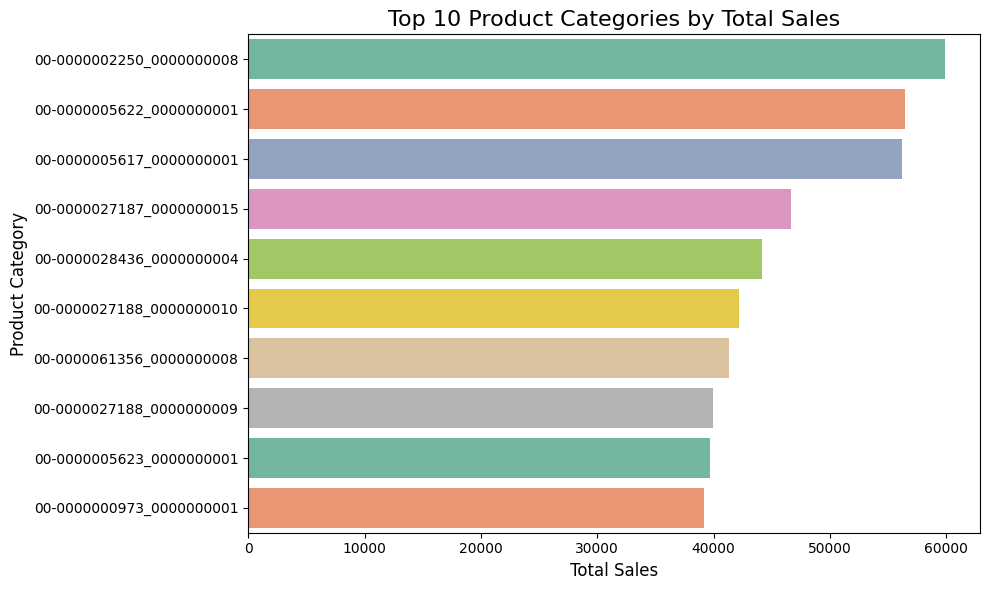

In [ ]:
# There is a 'product_category' column or we can use 'articleordernumber' to classify products
# For this example, we will use 'articleordernumber' is tied to product categories.

# Group by product category and calculate total sales
ecom_df['total_sales'] = ecom_df['quantity'] * ecom_df['price']
category_sales = ecom_df.groupby('articleordernumber')['total_sales'].sum().reset_index()

# Sort by total sales and get the top categories
top_category_sales = category_sales.nlargest(10, 'total_sales')

# Plotting total sales by product category
plt.figure(figsize=(10, 6))
sns.barplot(x='total_sales', y='articleordernumber', data=top_category_sales, palette='Set2')
plt.title('Top 10 Product Categories by Total Sales', fontsize=16)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()



Customer Purchase Behavior Over Time (Pie Chart Version - Top N Days)

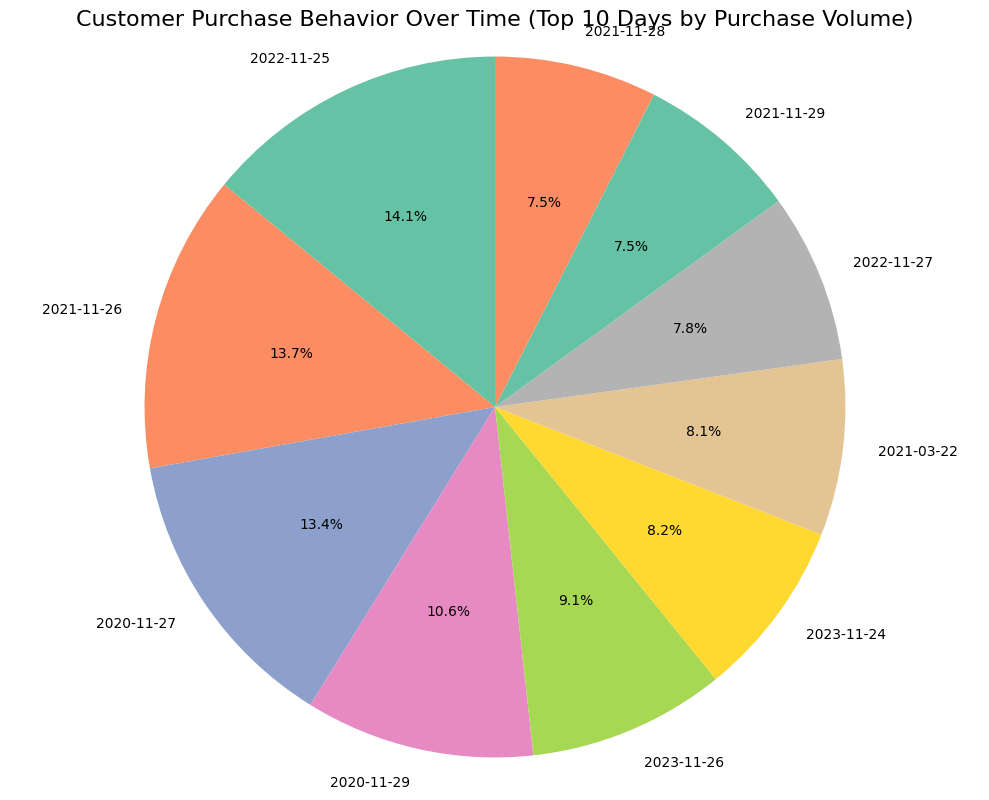

In [ ]:
 # Group by date and sum the quantities purchased each day
ecom_df['date'] = ecom_df['ordertime'].dt.date
daily_sales = ecom_df.groupby('date')['quantity'].sum().reset_index()

# Select top N days with the highest sales (e.g., top 10)
top_daily_sales = daily_sales.nlargest(10, 'quantity')

# Plotting the pie chart for daily sales over time
plt.figure(figsize=(10, 8))
plt.pie(top_daily_sales['quantity'], labels=top_daily_sales['date'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2", len(top_daily_sales)))
plt.title('Customer Purchase Behavior Over Time (Top 10 Days by Purchase Volume)', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()


Total Revenue per Product (articleordernumber)

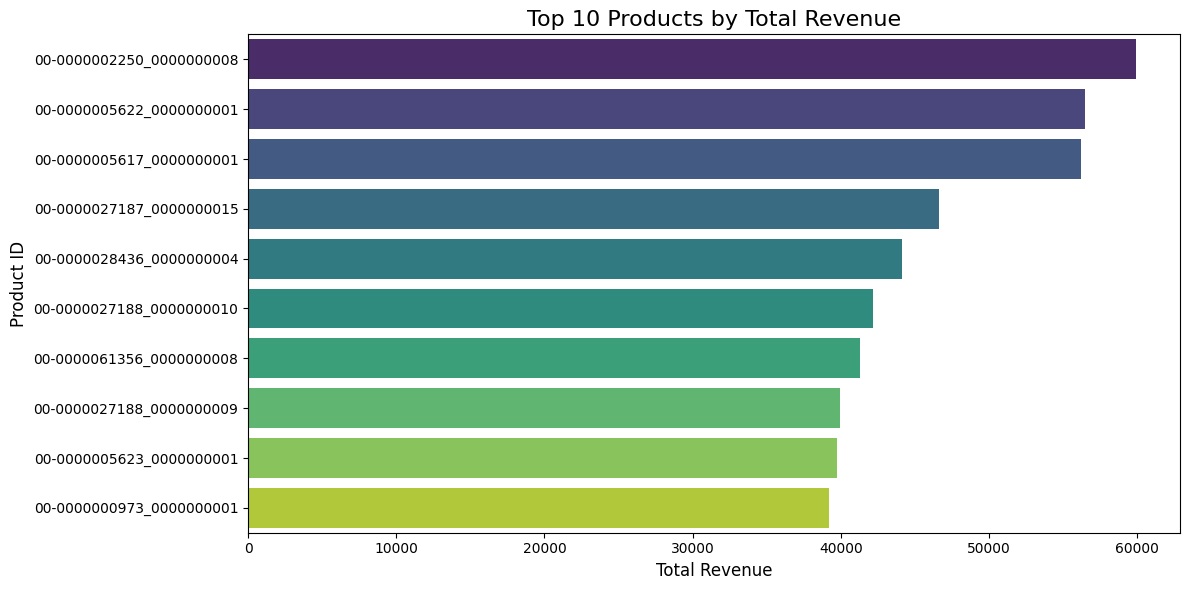

In [ ]:
# Calculate total revenue per product
ecom_df['revenue'] = ecom_df['quantity'] * ecom_df['price']
product_revenue = ecom_df.groupby('articleordernumber')['revenue'].sum().reset_index()

# Sort by revenue and get the top 10 products
top_product_revenue = product_revenue.nlargest(10, 'revenue')

# Plotting total revenue by product
plt.figure(figsize=(12, 6))
sns.barplot(x='revenue', y='articleordernumber', data=top_product_revenue, palette='viridis')
plt.title('Top 10 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product ID', fontsize=12)
plt.tight_layout()
plt.show()


Customer Segmentation Based on Total Spend (Total Revenue)

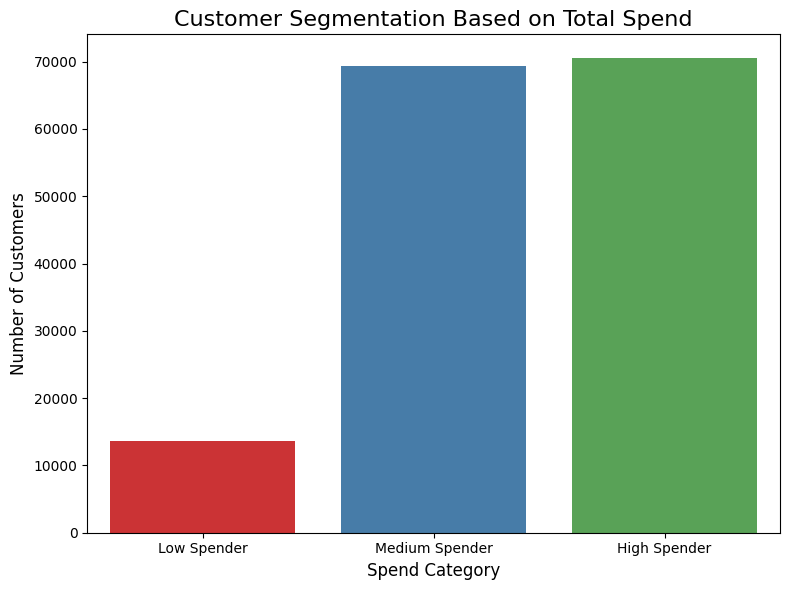

In [ ]:
# Calculate total spend for each customer
customer_spend = ecom_df.groupby('customernumber')['revenue'].sum().reset_index()

# Segmentation into high, medium, low spenders based on revenue thresholds
bins = [0, 50, 200, float('inf')]  # Adjust these values based on your data
labels = ['Low Spender', 'Medium Spender', 'High Spender']
customer_spend['spend_category'] = pd.cut(customer_spend['revenue'], bins=bins, labels=labels)

# Plotting customer segmentation
plt.figure(figsize=(8, 6))
sns.countplot(x='spend_category', data=customer_spend, palette='Set1')
plt.title('Customer Segmentation Based on Total Spend', fontsize=16)
plt.xlabel('Spend Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()


Sales Performance Over Time (Monthly Sales) - Fixed X-axis

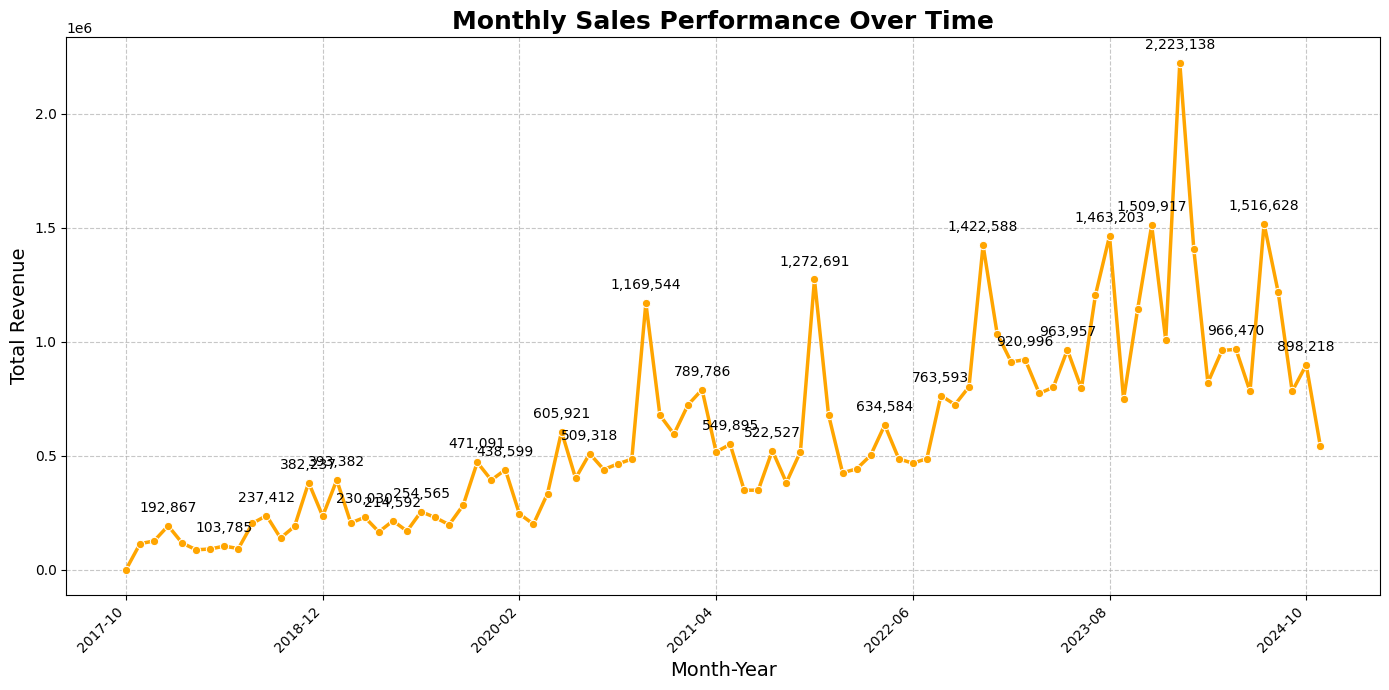

In [ ]:
# Extract month and year from 'ordertime'
ecom_df['month_year'] = ecom_df['ordertime'].dt.to_period('M')

# Convert 'month_year' to string format for plotting
ecom_df['month_year_str'] = ecom_df['month_year'].astype(str)

# Group by month and sum the revenue
monthly_sales = ecom_df.groupby('month_year_str')['revenue'].sum().reset_index()

# Plotting monthly sales performance with improved x-axis
plt.figure(figsize=(14, 7))
sns.lineplot(x='month_year_str', y='revenue', data=monthly_sales, marker='o', color='orange', linewidth=2.5)

# Customize x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xticks(ticks=range(0, len(monthly_sales), int(len(monthly_sales)/6)))  # Show every nth label

# Add gridlines for better visibility
plt.grid(True, linestyle='--', alpha=0.7)

# Add title and labels with larger fonts
plt.title('Monthly Sales Performance Over Time', fontsize=18, fontweight='bold')
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Total Revenue', fontsize=14)

# Add annotations for key peaks (for illustration)
for i in range(1, len(monthly_sales) - 1):
    if monthly_sales['revenue'].iloc[i] > monthly_sales['revenue'].iloc[i - 1] and monthly_sales['revenue'].iloc[i] > monthly_sales['revenue'].iloc[i + 1]:
        plt.annotate(f"{monthly_sales['revenue'].iloc[i]:,.0f}",
                     (monthly_sales['month_year_str'].iloc[i], monthly_sales['revenue'].iloc[i]),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='black')

# Adjust layout and display
plt.tight_layout()
plt.show()


Sales Performance Over Time (Yearly Sales) with Values on the Line Plot

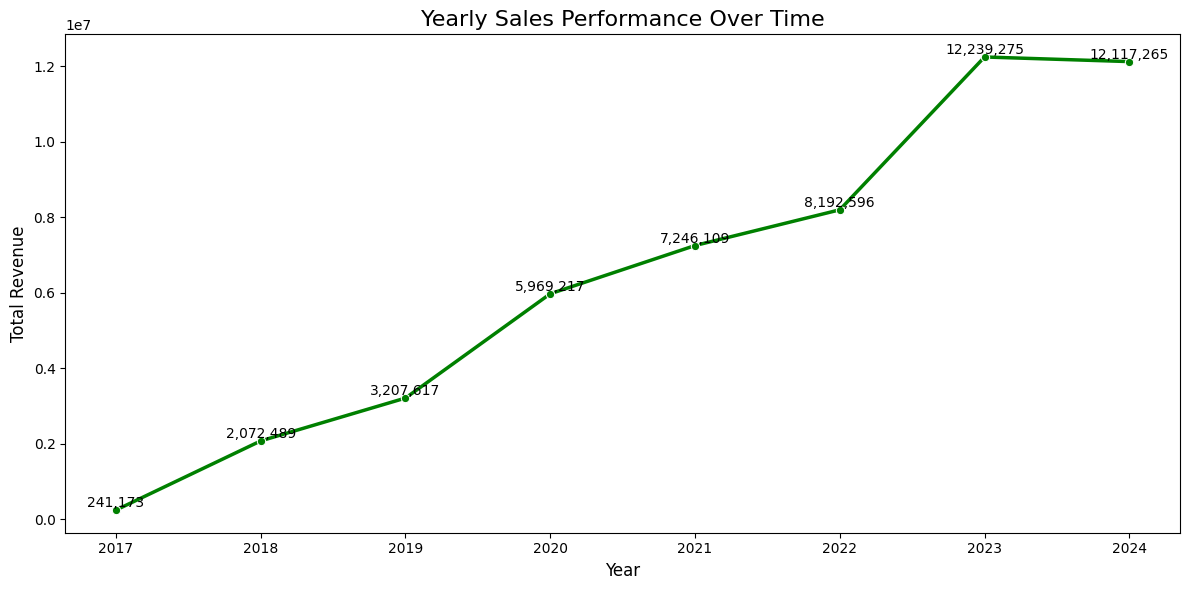

In [ ]:
# Extract year from 'ordertime'
ecom_df['year'] = ecom_df['ordertime'].dt.year

# Group by year and sum the revenue
yearly_sales = ecom_df.groupby('year')['revenue'].sum().reset_index()

# Plotting yearly sales performance
plt.figure(figsize=(12, 6))
ax = sns.lineplot(x='year', y='revenue', data=yearly_sales, marker='o', color='green', linewidth=2.5)

# Add title and labels
plt.title('Yearly Sales Performance Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Annotate each point on the line plot
for i in range(len(yearly_sales)):
    ax.text(yearly_sales['year'].iloc[i], yearly_sales['revenue'].iloc[i],
            f'{yearly_sales["revenue"].iloc[i]:,.0f}',
            horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='black')

# Show the plot
plt.tight_layout()
plt.show()


Seasonal Sales Heatmap

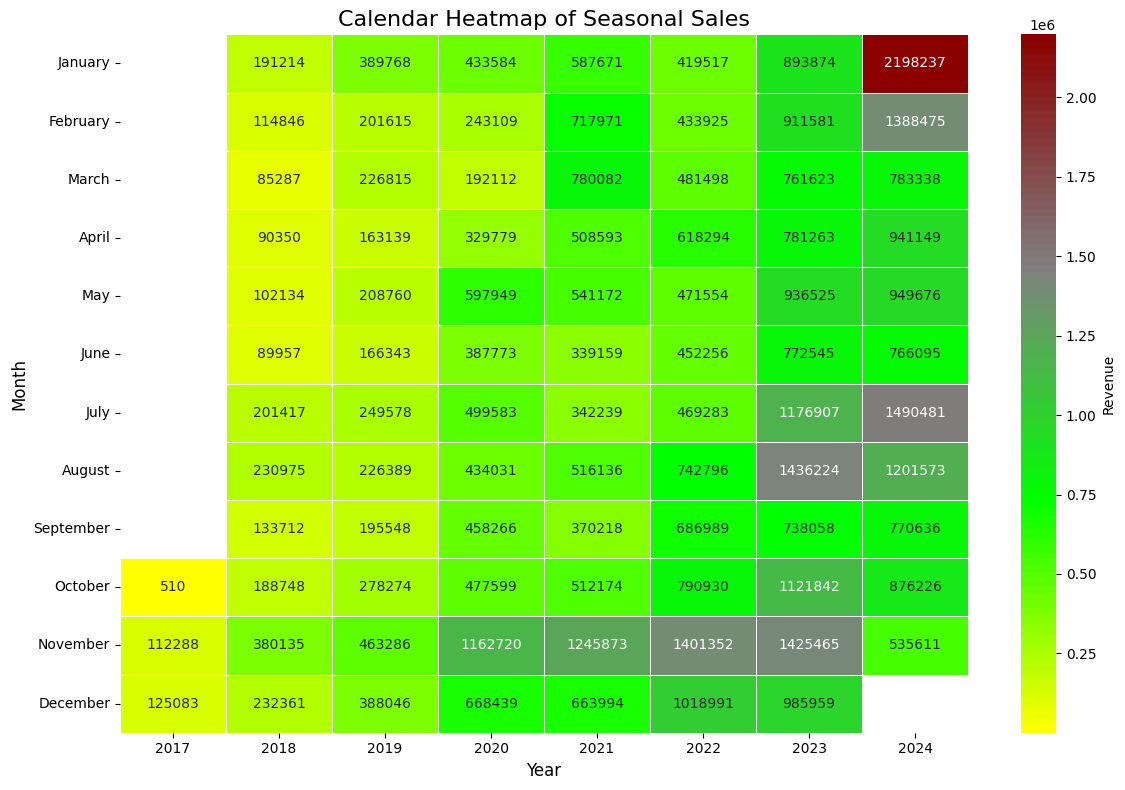

In [ ]:
# Extract year and month information
ecom_df['Year'] = ecom_df['ordertime'].dt.year
ecom_df['Month'] = ecom_df['ordertime'].dt.month_name()

# Calculate monthly revenue
monthly_revenue = ecom_df.groupby(['Year', 'Month'])['price'].sum().reset_index()

# Create pivot table
calendar_pivot = monthly_revenue.pivot_table(
    index='Month',
    columns='Year',
    values='price',
    aggfunc='sum'
)

# Edit month sort
calendar_pivot = calendar_pivot.reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Define custom colormap
colors = ["yellow", "lime", "gray", "darkred"]
n_bins = 100
cmap = LinearSegmentedColormap.from_list("high_contrast_colormap", colors, N=n_bins)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    calendar_pivot,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    linewidths=0.5,
    cbar_kws={'label': 'Revenue'}
)
plt.title('Calendar Heatmap of Seasonal Sales', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.tight_layout()
plt.show()


Association - Product Pairs Bought Together


Top 10 Product Pairs Bought Together:
                                        Product Pair  Count
0  (00-0000024885_0000000035, 00-0000024885_00000...     56
1  (00-0000024885_0000000035, 00-0000024885_00000...     53
2  (00-0000000647_0000000005, 00-0000000647_00000...     52
3  (00-0000061346_0000000033, 00-0000061346_00000...     49
4  (00-0000000647_0000000006, 00-0000000647_00000...     47
5  (00-0000024885_0000000035, 00-0000024885_00000...     44
6  (00-0000024885_0000000038, 00-0000024885_00000...     42
7  (00-0000024885_0000000039, 00-0000024885_00000...     42
8  (00-0000028157_0000000018, 00-0000028158_00000...     41
9  (00-0000024885_0000000036, 00-0000024885_00000...     40


<Figure size 1200x800 with 0 Axes>

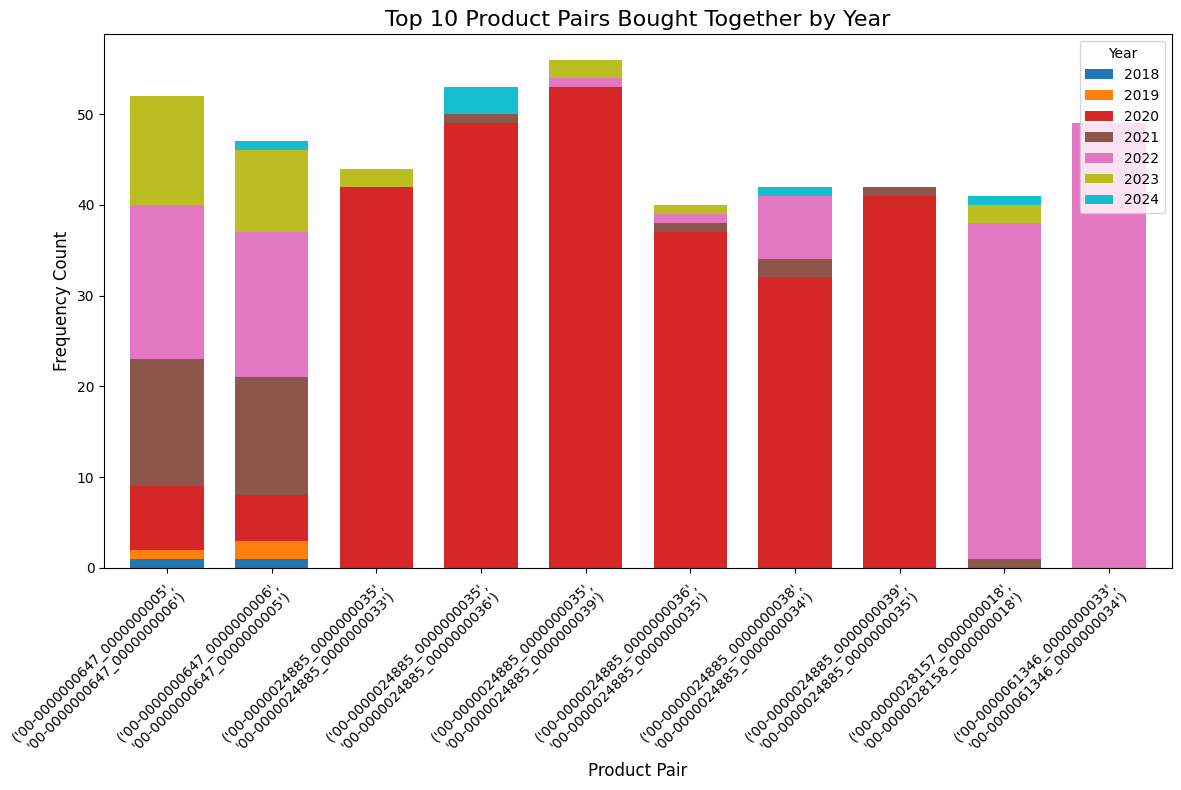

In [ ]:
# Ensure no missing data in required columns
ecom_df = ecom_df.dropna(subset=['ordernumber', 'articleordernumber'])

# Extract the year from the order time
ecom_df['year'] = pd.to_datetime(ecom_df['ordertime']).dt.year

# Step 1: Group products by 'ordernumber' and create product pairs
product_pairs = ecom_df.groupby(['ordernumber', 'year'])['articleordernumber'].apply(
    lambda products: list(combinations(products, 2)) if len(products) > 1 else []
).explode()

# Step 2: Count the frequency of each pair per year
pair_counts_by_year = product_pairs.groupby([product_pairs, product_pairs.index.get_level_values('year')]).size()
pair_counts_df = pair_counts_by_year.reset_index(name='Count')
pair_counts_df.columns = ['Product Pair', 'Year', 'Count']

# Step 3: Aggregate to find the total counts for all years and select the top 10 pairs
top_pairs = (
    pair_counts_df.groupby('Product Pair')['Count'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_pairs_df = pair_counts_df[pair_counts_df['Product Pair'].isin(top_pairs)]

# Pivot to create a matrix for plotting
plot_data = top_pairs_df.pivot(index='Product Pair', columns='Year', values='Count').fillna(0)

# --- Table Output ---
print("\nTop 10 Product Pairs Bought Together:")
print(top_pairs_df.groupby('Product Pair')['Count'].sum().sort_values(ascending=False).reset_index())

# Plotting the Stacked Bar Chart
plt.figure(figsize=(12, 8))
plot_data.plot(kind='bar', stacked=True, colormap='tab10', figsize=(12, 8), width=0.7)

# Properly synchronize x-axis labels
plt.xticks(
    ticks=range(len(plot_data.index)),
    labels=plot_data.index.astype(str),
    rotation=45,
    ha='right',
    fontsize=10,
    wrap=True
)
plt.title('Top 10 Product Pairs Bought Together by Year', fontsize=16)
plt.xlabel('Product Pair', fontsize=12)
plt.ylabel('Frequency Count', fontsize=12)
plt.legend(title='Year', fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()


# Customer Loyalty Analysis (Cohort Analysis - Heatmap)
To measure how loyal customers are, we can perform cohort analysis and plot a heatmap to show
how many customers stayed over multiple years.

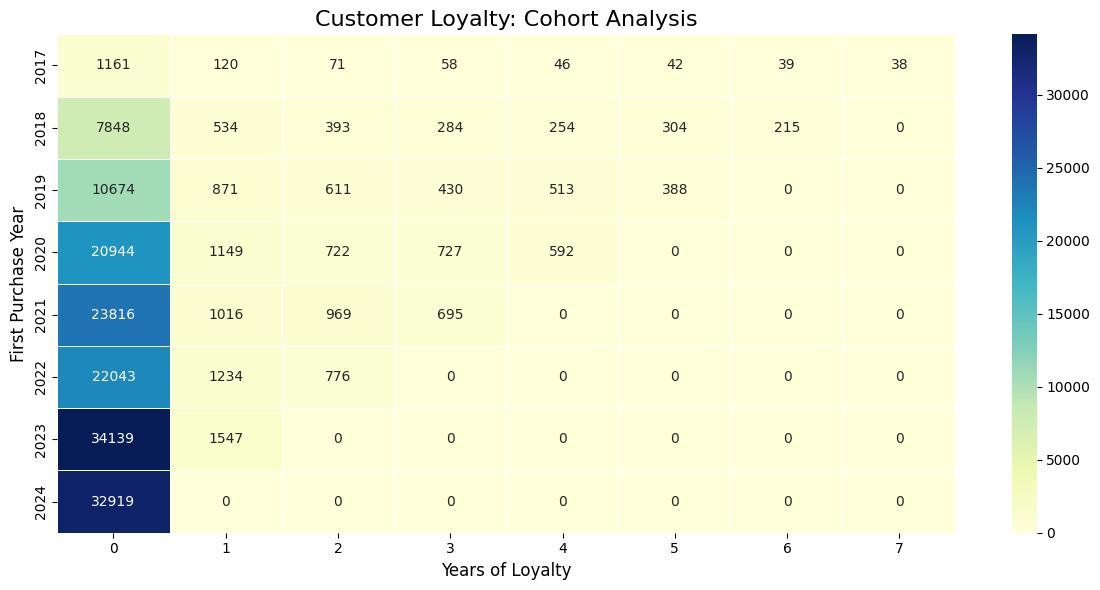

In [ ]:
# Ensure 'year' column is integer
ecom_df['year'] = ecom_df['year'].astype(int)

# Step 1: Determine the first purchase year for each customer
ecom_df['first_purchase_year'] = ecom_df.groupby('customernumber')['year'].transform('min')

# Step 2: Calculate the number of years a customer stayed
ecom_df['years_loyalty'] = ecom_df['year'] - ecom_df['first_purchase_year']

# Step 3: Create a cohort table
cohort_data = ecom_df.groupby(['first_purchase_year', 'years_loyalty'])['customernumber'].nunique().unstack().fillna(0)

# Convert to integers for proper display in the heatmap
cohort_data = cohort_data.astype(int)

# Step 4: Plotting the cohort analysis heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cohort_data, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)

plt.title('Customer Loyalty: Cohort Analysis', fontsize=16)
plt.xlabel('Years of Loyalty', fontsize=12)
plt.ylabel('First Purchase Year', fontsize=12)
plt.tight_layout()
plt.show()



Monthly Sales and Revenue Distribution for 2024

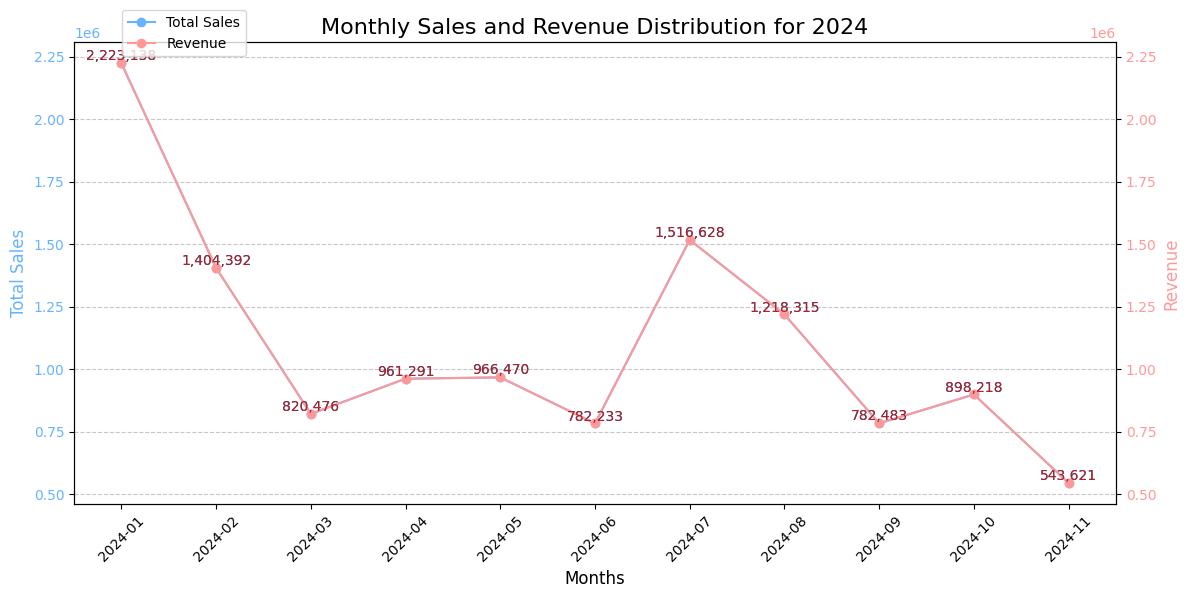

In [ ]:
# Aggregate total sales and revenue by month and year
sales_revenue_monthly = (
    ecom_df.groupby(['year', 'month_year_str'])[['total_sales', 'revenue']]
    .sum()
    .reset_index()
)

# Filter data for 2024
sales_revenue_2024 = sales_revenue_monthly[sales_revenue_monthly['year'] == 2024]

# Data for plotting
months = sales_revenue_2024['month_year_str']
total_sales = sales_revenue_2024['total_sales']
revenue = sales_revenue_2024['revenue']

# Plotting the dual-axis line chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot total sales
ax1.plot(months, total_sales, label='Total Sales', color='#66b3ff', marker='o', linestyle='-')
ax1.set_xlabel('Months', fontsize=12)
ax1.set_ylabel('Total Sales', fontsize=12, color='#66b3ff')
ax1.tick_params(axis='y', labelcolor='#66b3ff')
ax1.set_xticks(months)
ax1.set_xticklabels(months, rotation=45, fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate total sales
for i, value in enumerate(total_sales):
    ax1.text(months.iloc[i], value, f"{value:,.0f}", color='#0057b7', ha='center', va='bottom', fontsize=10)

# Plot revenue on the second y-axis
ax2 = ax1.twinx()
ax2.plot(months, revenue, label='Revenue', color='#ff9999', marker='o', linestyle='-')
ax2.set_ylabel('Revenue', fontsize=12, color='#ff9999')
ax2.tick_params(axis='y', labelcolor='#ff9999')

# Annotate revenue
for i, value in enumerate(revenue):
    ax2.text(months.iloc[i], value, f"{value:,.0f}", color='#b22222', ha='center', va='bottom', fontsize=10)

# Add title and legend
plt.title('Monthly Sales and Revenue Distribution for 2024', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 1), fontsize=10)
plt.tight_layout()

plt.show()


Customer Revenue Contribution

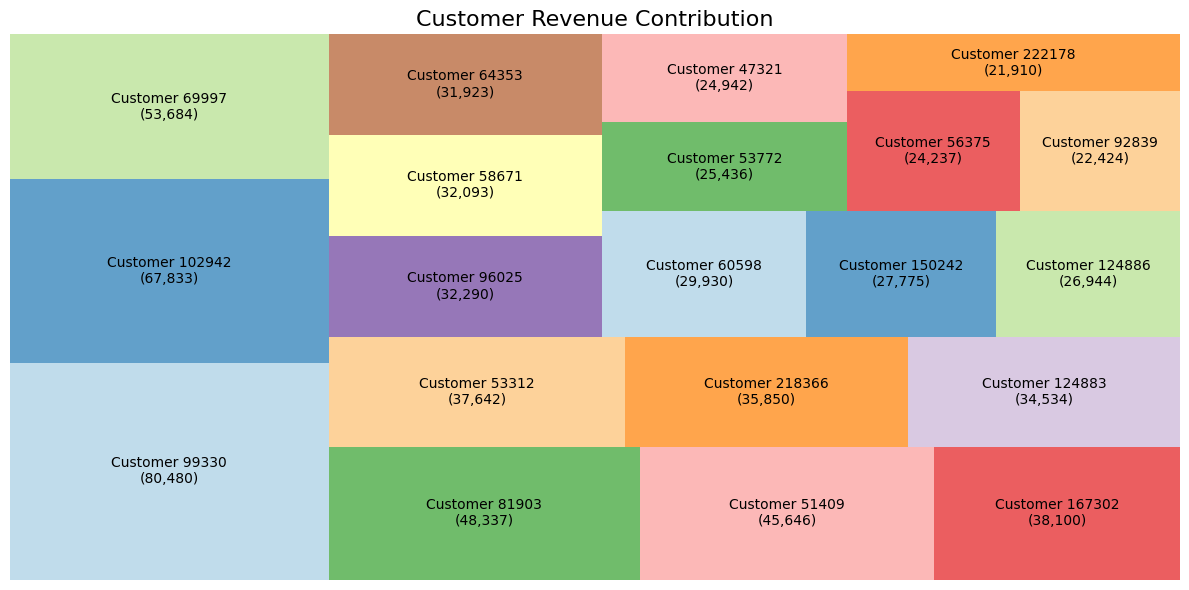

In [ ]:
# Calculate total revenue by customer
customer_revenue = ecom_df.groupby('customernumber')['revenue'].sum().reset_index()

# Filter out customers with zero revenue
customer_revenue = customer_revenue[customer_revenue['revenue'] > 0]

# Sort by revenue and create labels
customer_revenue_sorted = customer_revenue.sort_values(by='revenue', ascending=False).head(20)  # Limit to top 20 customers for clarity
labels = [
    f'Customer {int(x)}\n({y:,.0f})'
    for x, y in zip(customer_revenue_sorted['customernumber'], customer_revenue_sorted['revenue'])
]

# Plotting the treemap
plt.figure(figsize=(12, 6))
squarify.plot(
    sizes=customer_revenue_sorted['revenue'],
    label=labels,
    color=plt.cm.Paired.colors[:len(customer_revenue_sorted)],
    alpha=0.7
)
plt.title('Customer Revenue Contribution', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


Cumulative Revenue Contribution from Top N% Customers

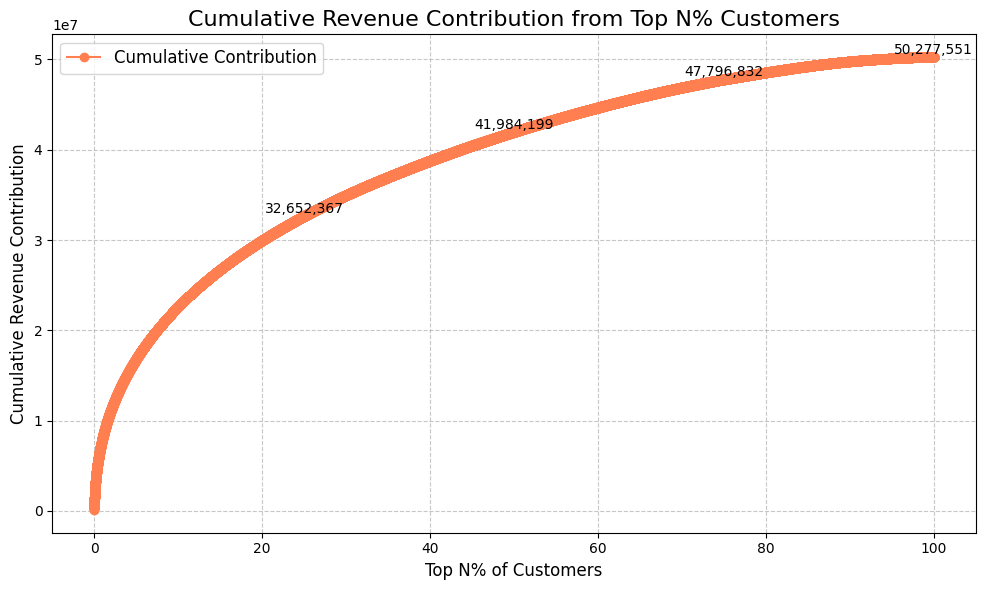

In [ ]:
# Her müşteri için toplam geliri hesapla
customer_revenue = ecom_df.groupby('userID')['price'].sum().reset_index()
customer_revenue = customer_revenue.rename(columns={'price': 'total_revenue'})

# Gelirlerine göre müşterileri azalan sıralamada diz
customer_revenue = customer_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)

# Kümülatif gelir ve yüzdelik dilim hesapla
customer_revenue['cumulative_revenue'] = customer_revenue['total_revenue'].cumsum()
customer_revenue['percentile'] = (customer_revenue.index + 1) / len(customer_revenue) * 100

# Yüzdelik dilim ve kümülatif gelir verilerini ayır
percentiles = customer_revenue['percentile']
cumulative_contributions = customer_revenue['cumulative_revenue']

# Belirli yüzdelik dilimler
annotation_percentiles = [10, 25, 50, 75, 100]
annotations = customer_revenue[customer_revenue['percentile'].isin(annotation_percentiles)]

# Grafiği çiz
plt.figure(figsize=(10, 6))
plt.plot(percentiles, cumulative_contributions, marker='o', color='coral', label='Cumulative Contribution')

# Belirli dilimlerde anotasyonları göster
for _, row in annotations.iterrows():
    plt.text(row['percentile'], row['cumulative_revenue'],
             f"{row['cumulative_revenue']:,.0f}", ha='center', va='bottom', fontsize=10, color='black')

plt.title('Cumulative Revenue Contribution from Top N% Customers', fontsize=16)
plt.xlabel('Top N% of Customers', fontsize=12)
plt.ylabel('Cumulative Revenue Contribution', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


In [ ]:
# Load ecom_df with necessary preprocessing
ecom_df['ordertime'] = pd.to_datetime(ecom_df['ordertime'])
ecom_df['price'] = pd.to_numeric(ecom_df['price'], errors='coerce')
ecom_df['quantity'] = pd.to_numeric(ecom_df['quantity'], errors='coerce')

In [ ]:
# Filtering for B2C restriction (e.g., based on 'userID' or 'customernumber', if applicable)
# Assuming customernumber differentiates B2B and B2C customers
b2c_df = ecom_df.dropna(subset=['customernumber'])

In [ ]:
# Compute the total revenue per transaction
b2c_df['total_revenue'] = b2c_df['price'] * b2c_df['quantity']

In [ ]:
# Prepare transactional summary data
observation_end_date = b2c_df['ordertime'].max()
summary = summary_data_from_transaction_data(
    b2c_df, customer_id_col='customernumber', datetime_col='ordertime', observation_period_end=observation_end_date, freq='W'
)

In [ ]:
# Add monetary value (average transaction value per customer)
monetary_value = (
    b2c_df.groupby('customernumber')['total_revenue'].mean().reset_index().rename(columns={'total_revenue': 'monetary_value'})
)
summary = summary.merge(monetary_value, on='customernumber', how='left')

In [ ]:
# Step 1: Fit the BG/NBD Model
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
print(bgf.summary)

           coef  se(coef)  lower 95% bound  upper 95% bound
r      0.040069  0.000483         0.039122         0.041016
alpha  6.139429  0.169930         5.806367         6.472491
a      0.629913  0.016806         0.596974         0.662852
b      0.744126  0.023211         0.698632         0.789620


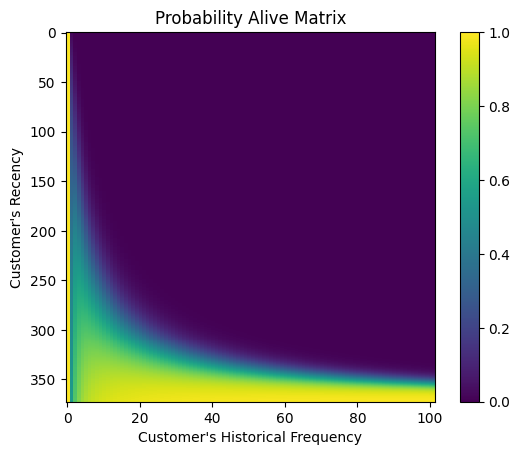

In [ ]:
# Step 2: Visualize Frequency/Recency Matrix
plot_probability_alive_matrix(bgf)
plt.title("Probability Alive Matrix")
plt.show()

# Business Perspective for Porbability Alive Matrix:

1. High Recency and Frequency (Top Right Corner):
- Customers in this area have purchased frequently and recently. They are very likely to be active, indicating strong customer engagement and loyalty. This segment is crucial for immediate marketing focus as they are likely to respond positively to new offers and promotions.

2. Low Frequency, regardless of Recency (Left Side):
- These customers have fewer interactions with the business. Despite some having recent transactions, their overall activity level is low, suggesting they are less engaged. Strategies to re-engage this group could include personalized marketing or special incentives to increase their purchase frequency.

3. Low Recency, regardless of Frequency (Bottom Area):
- Customers who haven’t purchased in a long time but may have a varied frequency history. These are at-risk or lapsed customers. Retargeting them through re-engagement campaigns or understanding the reasons for their inactivity could be valuable to potentially revive their interest.

## Conclusion:
- This matrix helps in segmenting customers based on their purchasing behavior, guiding targeted marketing strategies to optimize customer retention and lifetime value. Businesses can tailor their outreach efforts to maximize the effectiveness of their customer relationship management and marketing budget.

<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

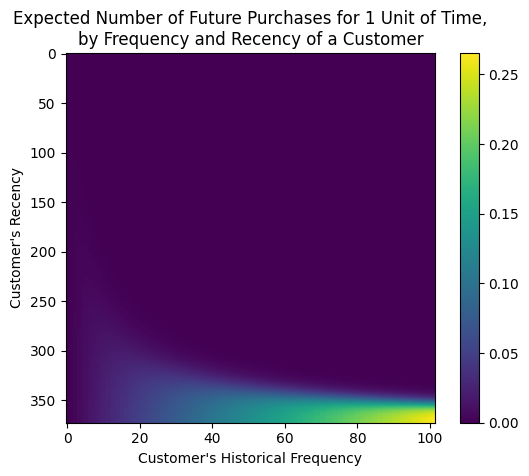

In [ ]:
plot_frequency_recency_matrix(bgf)

# Business Perspective Expected Number of Future Purchases:

1. High Recency and Frequency (Top Right Corner):
- The most vibrant colors in this area suggest that customers with high frequency and recent interactions are expected to make the most purchases in the next unit of time. This indicates strong ongoing engagement and implies that retaining these customers should be a priority since they contribute significantly to revenue.

2. Low Frequency, regardless of Recency (Left Side):
- These customers show very low future purchase expectations despite any recent activity. This suggests that although they might have interacted recently, their overall purchase history is sparse, indicating they are not deeply engaged. Tailored marketing efforts, possibly including special offers and personalized communication, could be used to increase their purchase frequency.

3. Low Recency, regardless of Frequency (Bottom Area):
- This area generally shows low expected purchases moving forward, indicating these are dormant or at-risk customers. Whether they purchased frequently in the past or not, their lack of recent activity makes them unlikely to contribute to short-term revenue without intervention. Re-engagement strategies, such as reactivation campaigns and loyalty incentives, are necessary to bring these customers back into the active customer fold.

# Conclusion:
- The information from this graph is crucial for optimizing marketing strategies and resource allocation, focusing efforts on segments that are predicted to bring the most value in the near future while identifying less engaged customers who might benefit from specific attention to boost their activity levels.

In [ ]:
# Step 3: Predict future purchases
t = 10  # Predict for 10 weeks
summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t, summary['frequency'], summary['recency'], summary['T']
)

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

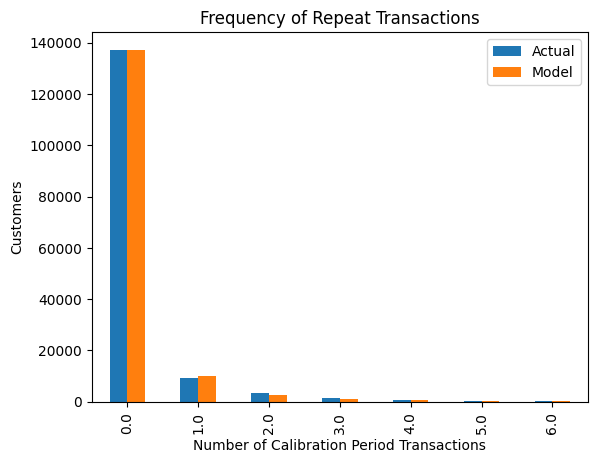

In [ ]:
# Model Validation
plot_period_transactions(bgf)

# Business Perspective:

1. 0 Transactions (Customers Who Did Not Repeat):
- The largest bars for both actual and model predictions indicate the majority of customers did not make repeat transactions within the calibration period. This suggests a high proportion of one-time buyers or low customer retention during this period.

2. 1+ Transactions (Repeat Customers):
- There is a significant drop-off in the number of customers who have repeat transactions, more so in the model's predictions than the actual data. This highlights potential areas where the business could focus on increasing repeat customer rates.

3. Model Accuracy:
- The model predictions generally underestimate the actual number of customers who made repeat purchases, except for those with zero repeat transactions. This could indicate that the model may need refinement to better predict repeat customer behavior.[we can do more refinment of model in future by manually making prototoype of algorithm.or we can use month, but this time we are not using month as frequency becoz it is taking alot of time to make a graph and process the things. because of limited resources]

# Behind the Scenes (Data and Model Working):
1. Data Segmentation:
- Customers are segmented based on the number of transactions they have made during a defined calibration period.

2. Predictive Modeling:
- The model, possibly a statistical or machine learning model, is trained on historical data to predict how often customers will make repeat purchases. It uses factors like purchase frequency and timing to estimate future behavior.

3. Calibration and Validation:
- The model's predictions are compared to actual outcomes to check for accuracy. This helps in refining the model to improve its predictions for future applications.

## Conclusion:
- The graph is crucial for understanding customer retention and repeat purchasing behavior. It shows where the model aligns with reality and where discrepancies lie, providing insights into potential areas for business strategy adjustment and model improvement to enhance customer engagement and predict their future behavior more accurately.

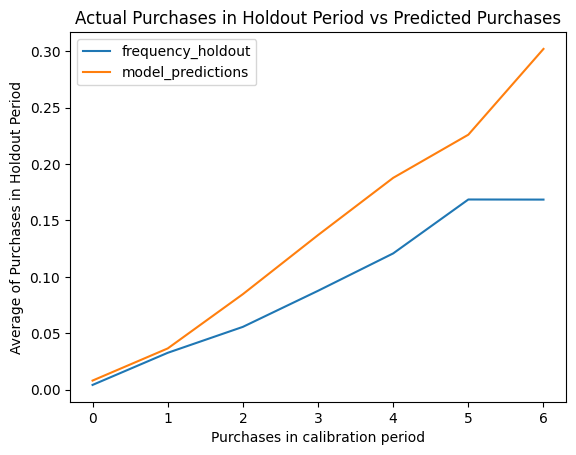

In [ ]:
# Step 4: Calibration and Holdout Data
calibration_period_end = observation_end_date - pd.Timedelta(weeks=12)
summary_cal_holdout = calibration_and_holdout_data(
    b2c_df, customer_id_col='customernumber', datetime_col='ordertime',
    calibration_period_end=calibration_period_end, observation_period_end=observation_end_date, freq='W'
)
bgf.fit(summary_cal_holdout['frequency_cal'], summary_cal_holdout['recency_cal'], summary_cal_holdout['T_cal'])
plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)
plt.show()

#### Business Perspective:
- Customer Retention and Value: From a business perspective, this analysis is crucial for understanding customer retention and value. By predicting future purchases, companies can identify high-value customers and tailor marketing strategies to retain them.

- Resource Allocation: It helps in optimal resource allocation. Knowing which customers are likely to make future purchases allows businesses to focus their marketing efforts and resources more efficiently.

- Forecasting and Planning: The model's predictions assist in inventory management, financial forecasting, and strategic planning by providing estimates of future sales volumes.

- Model Adjustment: If the model predictions significantly deviate from actual behavior (as it starts to show in the graph from the third purchase onward where the model consistently overestimates), it might indicate the need for model recalibration or the exploration of different modeling techniques that can capture customer behavior more accurately.

In [ ]:
# Step 5: Fit the Gamma-Gamma Model
returning_customers_summary = summary[summary['frequency'] > 0]

In [ ]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers_summary['frequency'], returning_customers_summary['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 16386 subjects, p: 4.21, q: 0.50, v: 4.02>

In [ ]:
# Step 6: Estimate CLV
clv = ggf.customer_lifetime_value(
    bgf, returning_customers_summary['frequency'], returning_customers_summary['recency'],
    returning_customers_summary['T'], returning_customers_summary['monetary_value'],
    time=12, discount_rate=0.01
)  # CLV for next 12 months

returning_customers_summary['CLV'] = clv

In [ ]:
# Output top customers by CLV
print(returning_customers_summary.sort_values(by='CLV', ascending=False).head(10))

        customernumber  frequency  recency      T  monetary_value  \
47005            99330      101.0    187.0  190.0      121.571752   
116638          217731       18.0     48.0   50.0      217.323077   
28770            69997       63.0    224.0  229.0      129.671498   
61922           124883       57.0    152.0  155.0      105.608563   
25071            64353       54.0    223.0  224.0      124.214008   
103896          197670       12.0     70.0   71.0      247.100000   
22367            60265       17.0    228.0  249.0      451.379310   
78490           153957       36.0    114.0  117.0      110.000000   
25367            64764       35.0    231.0  237.0      176.750000   
81083           158673       20.0     80.0   89.0      176.750000   

        predicted_purchases           CLV  
47005              4.925033  14562.358559  
116638             2.856312  10797.387899  
28770              2.546920   8363.418713  
61922              3.364134   8270.530833  
25071              2

# Columns Explanation:
- customernumber: Unique identifier for each customer.
- frequency: The number of repeat transactions a customer has made (beyond their first purchase).
- recency: Age of the customer in days at the time of their last purchase.
- T: Age of the customer in days since their first purchase up to the end of the period being studied.
- monetary_value: Average revenue per transaction (beyond the first purchase).
- predicted_purchases: Predicted number of purchases the customer will make in a future time period.
- CLV (Customer Lifetime Value): Predicted monetary value attributed to the entire future relationship with the customer.

# Business Perspective:
- High-Frequency, High-Recency Customers: Customers like those in the first row (e.g., customernumber 99330) who show high frequency and recency values are highly engaged and extremely valuable. They make frequent purchases and have done so recently, indicating strong loyalty and ongoing engagement with the brand.

- High Monetary Value: Customers such as in row 22367, despite a lower predicted purchase rate, have a very high average monetary value per transaction, leading to a high CLV. This suggests that even if they purchase less frequently, their high spending makes them significantly valuable.

- Predicted Purchases and CLV: The model provides predictions on how many more purchases each customer is expected to make in a defined future period and calculates the CLV based on these predictions and the monetary value. For example, a customer predicted to make around 4.9 additional purchases (customernumber 99330) with a high average spend per purchase results in a very high CLV.

# Conclusion:
- This output helps businesses prioritize and tailor their marketing efforts based on the predicted future behaviors and value of customers. It allows companies to focus resources on retaining high-value customers and potentially increasing engagement with those who have high monetary value but lower frequency or recency. This strategic insight drives better resource allocation and maximizes return on investment in marketing and customer relationship management.

Q. What CLV Measures
- CLV estimates the total revenue a business can expect from a customer over a specific time horizon, considering:
- The frequency of purchases.
- The recency of purchases.
- The monetary value of transactions.

# Key Verifications
1. Input Data Checks
- Monetary Value: Ensure that monetary values (monetary_value) are calculated as the mean transaction value per customer (not the total). Your output aligns with this logic (e.g., 217.32, 121.57).
- Frequency, Recency, T:
- Frequency = count of repeat purchases (your output shows reasonable values like 101, 18).
- Recency & T: Check if these align with your observation period in weeks. For instance:
recency=187, T=190 implies the customer purchased almost at the end of the period.
recency=48, T=50 implies the customer purchased early in the observation period.
2. BG/NBD Model
The predicted_purchases values (e.g., 4.92, 2.85) should reflect the expected number of transactions in the prediction period (e.g., t=12 months).
High-frequency customers (101.0) should logically have higher predicted_purchases.
3. Gamma-Gamma Model
The monetary_value should have a weak correlation (near 0) with frequency for the Gamma-Gamma model assumption to hold. Check this correlation to ensure validity.
CLV combines:
BG/NBD predicted transactions.
Gamma-Gamma average profit.
Discounted for the time horizon (12 months here).
Larger monetary values and high predicted purchases logically lead to higher CLVs.
4. Range of CLV
The CLV values (14,562, 10,797) depend on:
Observation period (longer observation = higher CLV).
Average transaction values and frequencies.
For high spenders with frequent purchases, CLVs in the range shown can be realistic.
Conclusion
Your output appears consistent:

Customers with high frequency and recency values (e.g., frequency=101.0, recency=187.0) have higher CLVs.
The calculation is proportional to both monetary_value and predicted_purchases.

In [ ]:
correlation = returning_customers_summary[['monetary_value', 'frequency']].corr()
print(correlation)


                monetary_value  frequency
monetary_value        1.000000  -0.055519
frequency            -0.055519   1.000000


- The correlation matrix indicates a weak negative correlation (-0.055) between monetary_value and frequency, which is an acceptable condition for using the Gamma-Gamma submodel to estimate the average transaction value and Customer Lifetime Value (CLV).

Q. What Does the Correlation Mean?
- Low Correlation: The assumption of independence between frequency and monetary value holds, allowing the Gamma-Gamma model to accurately predict average transaction value.
- Negative Value: The weak negative correlation means that, as frequency slightly increases, monetary value tends to decrease marginally, but the effect is negligible.

Step 1: Fit the Gamma-Gamma Submodel
- We will use the monetary value and frequency data to fit the Gamma-Gamma submodel.

In [ ]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers_summary['frequency'], returning_customers_summary['monetary_value'])

print(ggf)

<lifetimes.GammaGammaFitter: fitted with 16386 subjects, p: 4.21, q: 0.50, v: 4.02>


Step 2: Predict Average Transaction Value
- Estimate the expected average transaction value for each customer.

In [ ]:
# Predict the average transaction value
returning_customers_summary['expected_average_transaction_value'] = ggf.conditional_expected_average_profit(
    returning_customers_summary['frequency'],
    returning_customers_summary['monetary_value']
)

print(returning_customers_summary[['monetary_value', 'expected_average_transaction_value']].head(10))


    monetary_value  expected_average_transaction_value
0        70.059250                           84.077088
1        95.729906                           96.263252
2       125.250000                          127.649956
7       136.666667                          147.443439
10      139.375000                          140.758907
11      165.500000                          169.530024
12      176.000000                          189.263450
15      100.944444                          104.227276
17       94.403846                           95.587437
21      144.166667                          155.417594


# Columns Explanation:
- monetary_value: Actual average amount spent per transaction by the customer.

- expected_average_transaction_value: Model’s prediction of the average amount the customer will spend per transaction in the future.

# Business Perspective:
- Increased Spending Predictions: For most customers, the expected average transaction value is higher than their current monetary value. This suggests that the model predicts these customers will spend more per transaction in the future. For instance, customer at index 0 currently spends an average of $70.06, but is expected to spend about $84.08 in future transactions.

- Customer Spending Insights: The difference between actual and predicted values can inform strategies for upselling or cross-selling. For customers like the one at index 2, who already spend significantly ($125.25) and are expected to spend even more ($127.65), tailored marketing strategies offering higher-end products or services could be effective.

- Marketing and Sales Strategy Alignment: Knowing the expected transaction values helps in aligning marketing efforts with potential customer value. High-value prospects like the customer at index 12 (actual: $176, expected: $189.26) can be targeted more aggressively with premium offerings.

# Conclusion:
This table is particularly useful for marketing and sales teams to understand and predict customer spending behavior, helping them to fine-tune their strategies to enhance customer value and focus efforts on the most promising segments. It also helps in setting realistic expectations for future revenue per customer, which is crucial for budgeting and financial forecasting.








Step 3: Predict CLV with BG/NBD and Gamma-Gamma Models
- Using the fitted BG/NBD model and the Gamma-Gamma model, calculate the total CLV.

In [ ]:
# Calculate the total CLV
clv = ggf.customer_lifetime_value(
    bgf,  # BG/NBD model
    returning_customers_summary['frequency'],
    returning_customers_summary['recency'],
    returning_customers_summary['T'],
    returning_customers_summary['monetary_value'],
    time=12,  # Predict for the next 12 months
    discount_rate=0.01  # Monthly discount rate (approx. 12% annually)
)

# Add CLV to the summary
returning_customers_summary['CLV'] = clv

print(returning_customers_summary[['frequency', 'recency', 'T', 'monetary_value', 'expected_average_transaction_value', 'CLV']].head(10))


    frequency  recency      T  monetary_value  \
0         1.0      3.0  351.0       70.059250   
1        29.0    183.0  364.0       95.729906   
2         8.0    125.0  350.0      125.250000   
7         2.0    188.0  257.0      136.666667   
10       15.0    250.0  351.0      139.375000   
11        6.0     15.0  231.0      165.500000   
12        2.0    319.0  364.0      176.000000   
15        5.0    130.0  145.0      100.944444   
17       13.0    336.0  352.0       94.403846   
21        2.0    205.0  281.0      144.166667   

    expected_average_transaction_value         CLV  
0                            84.077088    1.718341  
1                            96.263252    0.000330  
2                           127.649956    3.211470  
7                           147.443439  179.611650  
10                          140.758907  225.719059  
11                          169.530024    0.004575  
12                          189.263450  197.500557  
15                          104.2272

# Business Insights:
- High Activity and Spending: Customers with higher frequency and recent transactions (e.g., rows 1, 10) generally show higher expected transaction values and significant CLV, indicating strong ongoing value.

- Potential Growth: Customers with lower frequency but high expected transaction values (e.g., rows 0, 7) suggest opportunities to increase engagement and maximize their lifetime value.

- Key Focus Areas: Monitoring CLV and expected values helps prioritize which customers to focus on for retention and upselling efforts, optimizing resource allocation for maximum return.

- This table is crucial for strategic planning in customer relationship management, targeting, and financial forecasting.

Step 4: Analyze and Validate CLV Predictions
Check Results: Ensure that the CLV values are reasonable and follow logical patterns (e.g., higher frequency and monetary value lead to higher CLV).
Visualize CLV Distribution

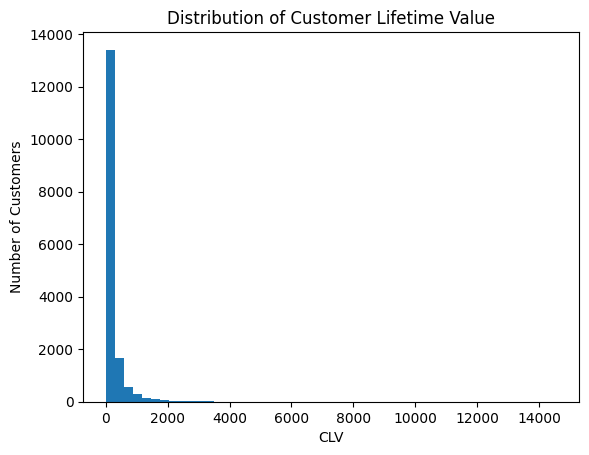

In [ ]:
plt.hist(returning_customers_summary['CLV'], bins=50)
plt.title('Distribution of Customer Lifetime Value')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.show()


# Step 5: Insights and Action
- Use the CLV predictions to identify high-value customers and prioritize them for marketing efforts.
Segment customers based on CLV values (e.g., high, medium, low) for targeted strategies.

In [ ]:
# Define CLV segments
def segment_customers(clv):
    if clv > 5000:  # High-value threshold
        return 'High'
    elif clv > 1000:  # Medium-value threshold
        return 'Medium'
    else:
        return 'Low'

# Apply segmentation
returning_customers_summary['CLV_segment'] = returning_customers_summary['CLV'].apply(segment_customers)

# View segmented data
print(returning_customers_summary[['frequency', 'recency', 'T', 'monetary_value', 'CLV', 'CLV_segment']].head())

# Analyze segment distribution
segment_distribution = returning_customers_summary['CLV_segment'].value_counts()
print(segment_distribution)


    frequency  recency      T  monetary_value         CLV CLV_segment
0         1.0      3.0  351.0       70.059250    1.718341         Low
1        29.0    183.0  364.0       95.729906    0.000330         Low
2         8.0    125.0  350.0      125.250000    3.211470         Low
7         2.0    188.0  257.0      136.666667  179.611650         Low
10       15.0    250.0  351.0      139.375000  225.719059         Low
CLV_segment
Low       15787
Medium      584
High         15
Name: count, dtype: int64


Business Insights:
Segment Distribution: The majority of customers are in the "Low" CLV segment, suggesting that most customers are not expected to bring significant future value under current engagement levels.
Customer Engagement: High-frequency and recent transactions do not necessarily correlate with a high CLV, indicating that even regular customers may have low projected lifetime value.
Targeting Strategy: This segmentation helps focus marketing and customer service resources more efficiently. It emphasizes the need to reevaluate engagement strategies for customers who transact often but are still classified as "Low" in CLV.
Summary Counts:
Low CLV Segment: 15,787 customers, indicating a large base of low-value customers.
Medium and High CLV Segments: Fewer customers, suggesting that higher-value customers are significantly rarer and potentially warrant tailored strategies to maximize their retention and value.

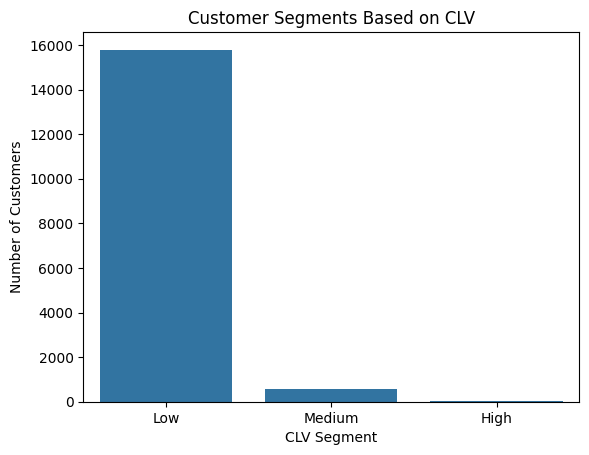

In [ ]:
sns.countplot(data=returning_customers_summary, x='CLV_segment', order=['Low', 'Medium', 'High'])
plt.title('Customer Segments Based on CLV')
plt.xlabel('CLV Segment')
plt.ylabel('Number of Customers')
plt.show()


Insights from Segmentation:
High-Value Customers:

Engage these customers with loyalty programs, exclusive offers, and personalized experiences to ensure retention.
Assign dedicated account managers or premium support.
Medium-Value Customers:

Target these customers with upselling and cross-selling campaigns to increase their purchase frequency or monetary value.
Encourage these customers to move into the high-value segment.
Low-Value Customers:

Implement cost-effective retention strategies such as automated email campaigns or product bundles.
Identify churn risk and develop reactivation strategies.

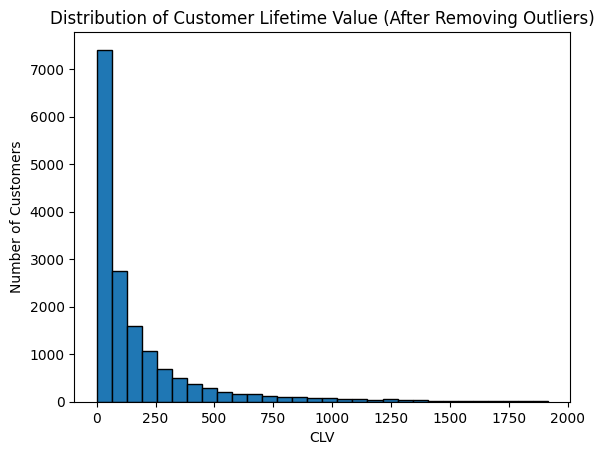

In [ ]:
# Remove outliers from the CLV column
# Define thresholds for outlier removal
lower_threshold = returning_customers_summary['CLV'].quantile(0.01)
upper_threshold = returning_customers_summary['CLV'].quantile(0.99)

# Filter data within thresholds
filtered_customers = returning_customers_summary[
    (returning_customers_summary['CLV'] >= lower_threshold) &
    (returning_customers_summary['CLV'] <= upper_threshold)
]
# Plot the CLV distribution after removing outliers
plt.hist(filtered_customers['CLV'], bins=30, edgecolor='black')
plt.title('Distribution of Customer Lifetime Value (After Removing Outliers)')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.show()


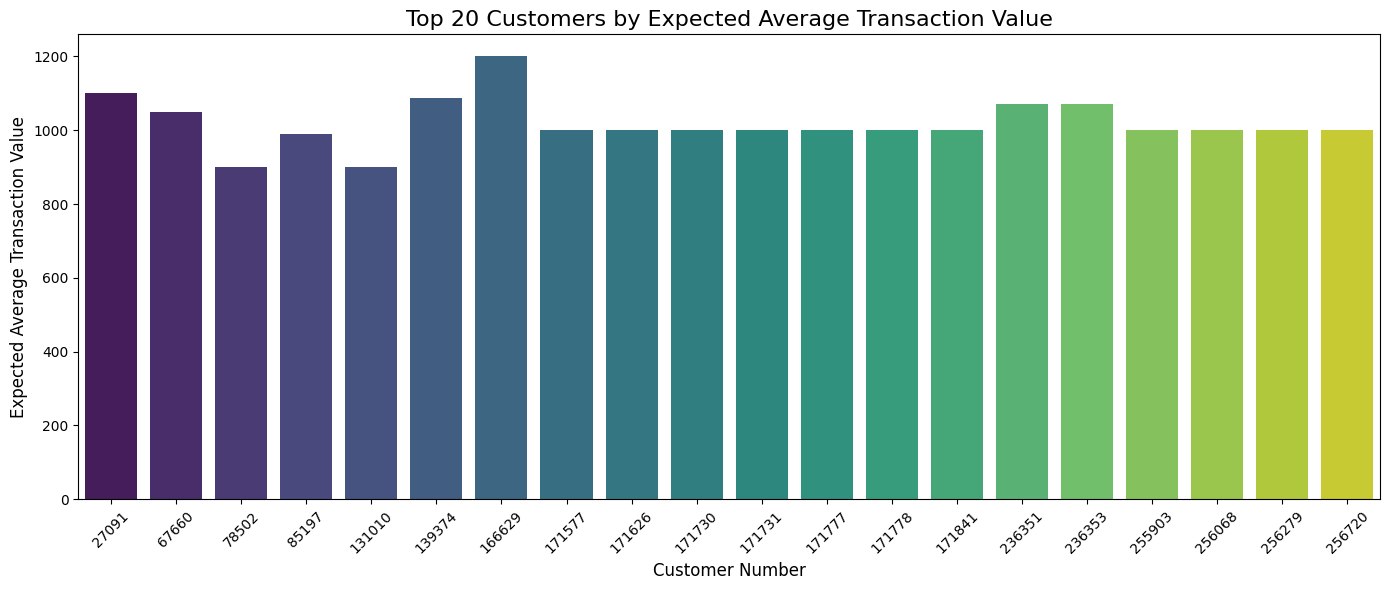

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Expected Average Transaction Value'yu Müşteriler İçin Hesapla
customer_expected_values = ecom_df.groupby('customernumber').agg(
    total_spent=('price', 'sum'),
    transaction_count=('ordernumber', 'count')
).reset_index()

customer_expected_values['expected_average_transaction_value'] = (
    customer_expected_values['total_spent'] / customer_expected_values['transaction_count']
)

# Görselleştirme: Expected Average Transaction Value
plt.figure(figsize=(14, 6))
sns.barplot(
    data=customer_expected_values.sort_values('expected_average_transaction_value', ascending=False).head(20),
    x='customernumber',
    y='expected_average_transaction_value',
    palette='viridis'
)
plt.title('Top 20 Customers by Expected Average Transaction Value', fontsize=16)
plt.xlabel('Customer Number', fontsize=12)
plt.ylabel('Expected Average Transaction Value', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


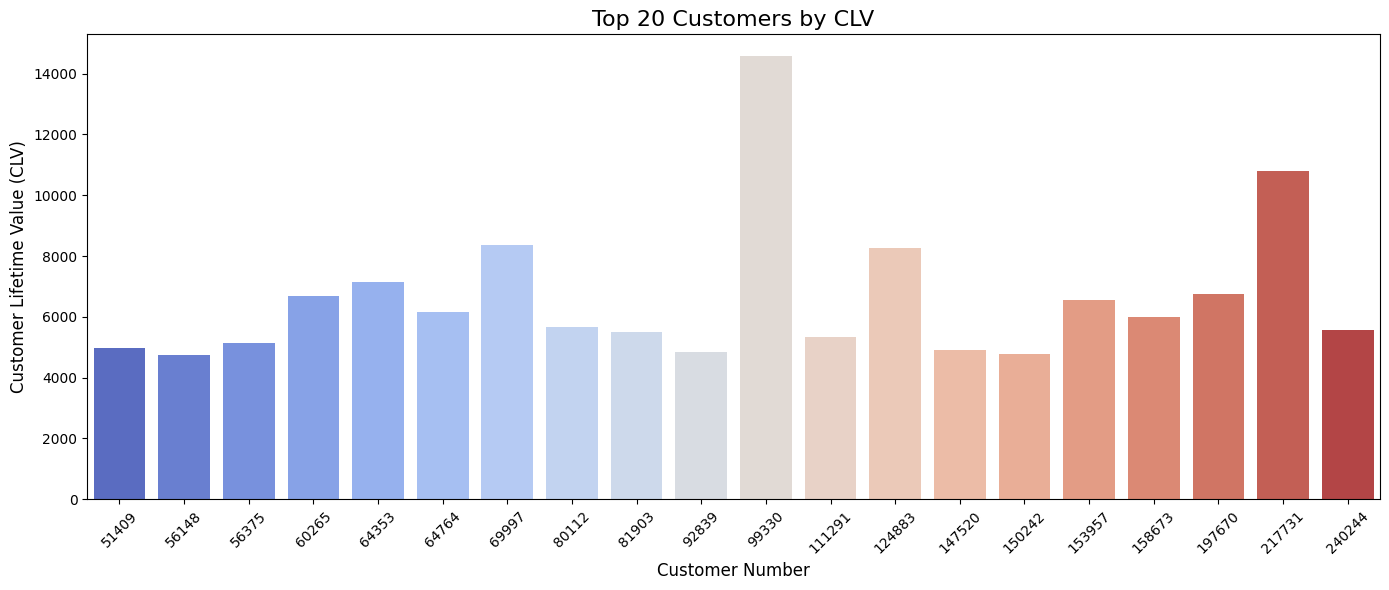

In [ ]:
# Müşterilere Göre CLV'yi Hazırla
customer_clv = returning_customers_summary[['customernumber', 'CLV']]

# Görselleştirme: CLV
plt.figure(figsize=(14, 6))
sns.barplot(
    data=customer_clv.sort_values('CLV', ascending=False).head(20),
    x='customernumber',
    y='CLV',
    palette='coolwarm'
)
plt.title('Top 20 Customers by CLV', fontsize=16)
plt.xlabel('Customer Number', fontsize=12)
plt.ylabel('Customer Lifetime Value (CLV)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- This radar chart visually compares top customers across several key metrics—expected average transaction value, customer lifetime value (CLV), total spent, and transaction count—highlighting their performance relative to each other on a common scale.

- This parallel coordinates graph visualizes and compares the normalized values of different metrics (expected average transaction value, CLV, total spent, and transaction count) for top customers, allowing for an easy comparison of how each customer ranks across these various dimensions.


# Why we don't work with Time as month in ecom data?

- The error is caused because freq='M' is not directly supported in summary_data_from_transaction_data. Instead, it requires a time unit with unambiguous durations like days (D) or weeks (W). However, we can calculate the summary based on months using an alternative approach by converting time differences to months.



- Solution:
      - We'll calculate the recency, T, and frequency using months as the time unit manually and pass these to the model.



- After the solution we stuck in large penalizer coeffficient, if we try to use it, then it give us very nonsense graph with the help of model that does not make any sense.


- from documentation we found out if we work with day or week data for ecomerce it will more suitable -- stackoverflow

- when we go for month data it some time give us misleading result that should be checked with domain expert and also give very shaddy and meaning less graph.